# **Experiment Notebook**



In [312]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [313]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [314]:
!pip install -i https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple my-krml-25934391==2025.8.30.4

Looking in indexes: https://test.pypi.org/simple/, https://pypi.org/simple


In [315]:
!pip install matplotlib seaborn

In [316]:
# <Student to fill this section>
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [317]:
from pathlib import Path
from types import SimpleNamespace

In [318]:
path = Path(r"C:\Users\smita\Desktop\MDSI\Sem2\AdvMLA\Asignment1\CSVs")
path.mkdir(parents=True, exist_ok=True)
at = SimpleNamespace(folder_path=path)

In [319]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

---
## A. Project Description


In [320]:
# <Student to fill this section>
student_name = "Shreyash Narayane"
student_id = "25934391"
group_id = "23"

In [321]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [322]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [323]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [324]:
# <Student to fill this section>
business_use_case_description = """
The project enables NBA teams to optimize their draft preparation by providing data-driven probability assessments of which college players are most likely to be drafted. Teams can prioritize limited scouting resources on high-probability prospects rather than evaluating every college player. The model helps construct objective draft boards and identify statistical outliers who may be undervalued by traditional scouting. Teams can assess whether target players will likely be available at specific draft positions, informing trade decisions. This transforms subjective draft preparation into a systematic, evidence-based process that complements traditional scouting methods.
"""

In [325]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [326]:
# <Student to fill this section>
business_objectives = """
For accurate results, teams could efficiently allocate scouting resources to legitimate prospects, saving time and budget on low-probability players. Better draft positioning decisions would lead to acquiring target players at optimal draft slots. Improved long-term roster construction through data-driven player evaluation.
//
However, incorrect results can be costly in multiple ways. False positives waste valuable scouting resources on players who won't be drafted, reducing time available for evaluating actual prospects, while false negatives cause teams to overlook genuine draft talent that competitors may acquire. Poor draft positioning decisions resulting from inaccurate predictions lead to reaching for overvalued players or losing target players to other teams. Most critically, systematic model bias could result in consistently flawed draft strategies that impact team competitiveness over multiple seasons, creating financial losses from inefficient resource allocation and suboptimal draft picks that fail to contribute meaningfully to team success."""

In [327]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [328]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
The probability predictions will be integrated into NBA teams' draft preparation workflows as a filtering and prioritization tool for scouting assignments and prospect rankings. Teams will use the scores to supplement traditional scouting reports during draft meetings and guide decisions about player workouts and invitations. The results will also assist in trade negotiations by providing objective assessments of player availability at different draft positions.
//
Primary users will be NBA front office personnel including general managers, scouting directors, and analytics departments who make draft-related decisions.
//
College basketball players will be directly impacted as predictions influence whether they receive professional scouting attention and workout invitations. Player agents, college coaches, and competing NBA teams will also be impacted through recruiting implications and competitive dynamics in identifying undervalued or overvalued prospects.
"""

In [329]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [330]:
# <Student to fill this section>
train = pd.read_csv(path / "train.csv")

In [331]:
test = pd.read_csv(path / "test.csv")

In [332]:
#test = pd.read_csv("C:/Users/smita/Desktop/MDSI/Sem2/AdvMLA/Asignment1/CSVs/test.csv")

In [333]:
#Shape of Train set
print("Train dataset shape:", train.shape)

Train dataset shape: (14774, 62)


In [334]:
print(train.columns.tolist())

['team', 'conf', 'GP', 'Min_per', 'Ortg', 'usg', 'eFG', 'TS_per', 'ORB_per', 'DRB_per', 'AST_per', 'TO_per', 'FTM', 'FTA', 'FT_per', 'twoPM', 'twoPA', 'twoP_per', 'TPM', 'TPA', 'TP_per', 'blk_per', 'stl_per', 'ftr', 'yr', 'ht', 'porpag', 'adjoe', 'pfr', 'year', 'type', 'Rec_Rank', 'ast_tov', 'rimmade', 'rimmade_rimmiss', 'midmade', 'midmade_midmiss', 'rim_ratio', 'mid_ratio', 'dunksmade', 'dunksmiss_dunksmade', 'dunks_ratio', 'drtg', 'adrtg', 'dporpag', 'stops', 'bpm', 'obpm', 'dbpm', 'gbpm', 'mp', 'ogbpm', 'dgbpm', 'oreb', 'dreb', 'treb', 'ast', 'stl', 'blk', 'pts', 'player_id', 'drafted']


In [335]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14774 entries, 0 to 14773
Data columns (total 62 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   team                 14774 non-null  object 
 1   conf                 14774 non-null  object 
 2   GP                   14774 non-null  int64  
 3   Min_per              14774 non-null  float64
 4   Ortg                 14774 non-null  float64
 5   usg                  14774 non-null  float64
 6   eFG                  14774 non-null  float64
 7   TS_per               14774 non-null  float64
 8   ORB_per              14774 non-null  float64
 9   DRB_per              14774 non-null  float64
 10  AST_per              14774 non-null  float64
 11  TO_per               14774 non-null  float64
 12  FTM                  14774 non-null  int64  
 13  FTA                  14774 non-null  int64  
 14  FT_per               14774 non-null  float64
 15  twoPM                14774 non-null 

In [336]:
train.head(5)

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc,0.0
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6,0.0
3,Virginia,ACC,28,59.2,88.2,21.7,46.2,47.25,1.5,9.7,...,1.45913,0.3214,2.0357,2.3571,3.0000,1.2857,0.0714,7.7500,01285c6b-bc71-4fa8-941a-28cf3976a117,0.0
4,Elon,SC,21,13.7,47.5,15.0,26.2,26.20,5.8,2.3,...,-3.75694,0.3810,0.1429,0.5238,0.4286,0.1905,0.0000,0.5714,a962c41c-55ff-461e-8585-db32e4fa0580,0.0


In [337]:
train.tail(5)

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
14769,Virginia,ACC,29,35.0,83.6,15.1,34.4,37.32,6.1,18.6,...,3.019260,0.7586,2.2069,2.9655,0.8276,0.6207,0.2069,2.4138,2678f4e0-cfa4-491a-88cb-2207f78e21f7,0.0
14770,SMU,CUSA,27,20.5,87.9,12.9,45.2,44.78,2.9,7.3,...,-0.557959,0.2222,0.5556,0.7778,0.3704,0.2963,0.0000,1.6296,45a8a388-7cf9-4ceb-a843-3b22875f6016,0.0
14771,Virginia,ACC,28,84.7,105.8,25.5,45.9,53.72,5.4,14.5,...,0.787983,1.6786,4.3571,6.0357,2.7857,1.0000,0.1071,16.5714,20a2285a-acb6-41f4-810b-9f4d92914ef3,0.0
14772,Arkansas Pine Bluff,SWAC,8,2.5,28.4,18.9,0.0,11.94,3.8,0.0,...,-4.730150,0.1000,0.0000,0.1000,0.2000,0.1000,0.0000,0.6000,1d19a682-2364-4874-abdc-0e340443b6c3,0.0
14773,South Carolina,SEC,11,2.7,86.7,13.6,33.3,36.70,3.1,13.8,...,1.035280,0.1667,0.6667,0.8333,0.0000,0.0833,0.0000,0.6667,484f5c19-1ff8-42c5-bddd-3615614c4c1b,0.0


In [338]:
print(train.describe())

                 GP       Min_per          Ortg           usg           eFG  \
count  14774.000000  14774.000000  14774.000000  14774.000000  14774.000000   
mean      21.251726     25.870123     85.771707     17.256674     41.507628   
std       10.517642     23.639878     34.164203      6.332899     20.610900   
min        1.000000      0.000000      0.000000      0.000000      0.000000   
25%       12.000000      4.200000     75.600000     13.900000     34.800000   
50%       25.000000     19.600000     91.300000     17.200000     44.900000   
75%       30.000000     42.900000    102.600000     20.600000     51.400000   
max       41.000000     94.300000    407.300000     50.000000    150.000000   

             TS_per       ORB_per       DRB_per       AST_per        TO_per  \
count  14774.000000  14774.000000  14774.000000  14774.000000  14774.000000   
mean      44.566821      5.644010     11.992744      9.776100     21.493326   
std       19.622173     15.097867     15.348129    

In [339]:
print("Summary statistics:")
print(train.describe().T)

Summary statistics:
                       count         mean        std          min  \
GP                   14774.0    21.251726  10.517642     1.000000   
Min_per              14774.0    25.870123  23.639878     0.000000   
Ortg                 14774.0    85.771707  34.164203     0.000000   
usg                  14774.0    17.256674   6.332899     0.000000   
eFG                  14774.0    41.507628  20.610900     0.000000   
TS_per               14774.0    44.566821  19.622173     0.000000   
ORB_per              14774.0     5.644010  15.097867     0.000000   
DRB_per              14774.0    11.992744  15.348129     0.000000   
AST_per              14774.0     9.776100   9.906416     0.000000   
TO_per               14774.0    21.493326  13.979387     0.000000   
FTM                  14774.0    20.152092  26.550462     0.000000   
FTA                  14774.0    30.266482  37.293688     0.000000   
FT_per               14774.0     0.523931   0.289864     0.000000   
twoPM         

In [340]:
#Shape of Test set
print("Test dataset shape:", test.shape)

Test dataset shape: (1297, 61)


In [341]:
print(test.columns.tolist())

['team', 'conf', 'GP', 'Min_per', 'Ortg', 'usg', 'eFG', 'TS_per', 'ORB_per', 'DRB_per', 'AST_per', 'TO_per', 'FTM', 'FTA', 'FT_per', 'twoPM', 'twoPA', 'twoP_per', 'TPM', 'TPA', 'TP_per', 'blk_per', 'stl_per', 'ftr', 'yr', 'ht', 'porpag', 'adjoe', 'pfr', 'year', 'type', 'Rec_Rank', 'ast_tov', 'rimmade', 'rimmade_rimmiss', 'midmade', 'midmade_midmiss', 'rim_ratio', 'mid_ratio', 'dunksmade', 'dunksmiss_dunksmade', 'dunks_ratio', 'drtg', 'adrtg', 'dporpag', 'stops', 'bpm', 'obpm', 'dbpm', 'gbpm', 'mp', 'ogbpm', 'dgbpm', 'oreb', 'dreb', 'treb', 'ast', 'stl', 'blk', 'pts', 'player_id']


In [342]:
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1297 entries, 0 to 1296
Data columns (total 61 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   team                 1297 non-null   object 
 1   conf                 1297 non-null   object 
 2   GP                   1297 non-null   int64  
 3   Min_per              1297 non-null   float64
 4   Ortg                 1297 non-null   float64
 5   usg                  1297 non-null   float64
 6   eFG                  1297 non-null   float64
 7   TS_per               1297 non-null   float64
 8   ORB_per              1297 non-null   float64
 9   DRB_per              1297 non-null   float64
 10  AST_per              1297 non-null   float64
 11  TO_per               1297 non-null   float64
 12  FTM                  1297 non-null   int64  
 13  FTA                  1297 non-null   int64  
 14  FT_per               1297 non-null   float64
 15  twoPM                1297 non-null   i

In [343]:
test.head(5)

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id
0,UC Davis,BW,8,2.2,51.7,13.4,30.0,30.00,0.0,14.3,...,-11.240100,-4.721030,0.1000,0.6000,0.7000,0.2000,0.1000,0.0000,1.5000,c6d3ce49-28b6-4756-8061-b2bd68730c52
1,Campbell,BSth,25,16.4,85.0,25.2,50.0,52.10,2.0,11.8,...,-2.972020,-1.741870,0.1481,0.9259,1.0741,0.1481,0.4074,0.1111,4.0741,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5
2,Weber St.,BSky,29,50.5,117.8,16.8,61.8,59.77,12.3,17.1,...,0.739055,-0.259202,2.1562,2.7500,4.9062,0.7188,0.4062,1.0625,6.7500,0cf3e822-9446-4285-b7ed-7c19d8e976fe
3,Ohio,MAC,17,14.9,85.8,13.1,34.9,34.88,5.1,13.7,...,-3.339750,-0.573442,0.5789,1.5789,2.1579,0.5263,0.1579,0.1579,2.6842,b1a88de0-6852-4597-bb92-9164b40758e5
4,New Mexico St.,WAC,26,17.1,85.8,10.8,48.1,49.46,5.6,17.4,...,-4.184970,1.718210,0.4643,1.1429,1.6071,0.1071,0.0714,0.4286,1.7500,97c327ce-d051-40f0-9166-1a43557c3c92


In [344]:
test.tail(5)

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id
1292,Idaho,BSky,10,2.2,32.6,9.7,0.0,12.66,0.0,4.5,...,-11.4485,-1.63890,0.0,0.1,0.1,0.1,0.2,0.0,0.1,de9d5043-6934-4eb4-92c6-cb767803a119
1293,Tennessee St.,OVC,3,0.2,0.0,37.9,0.0,0.00,0.0,0.0,...,-23.6546,-15.89130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2b67cd1e-e104-4540-981e-d828961b210e
1294,Niagara,MAAC,1,0.1,0.0,48.9,0.0,0.00,0.0,0.0,...,-22.4688,-17.43960,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9eded9ee-0eb4-49f4-914a-f58924797bdf
1295,Texas Southern,SWAC,1,0.6,48.5,28.9,0.0,52.63,0.0,15.9,...,-13.3727,-3.24061,0.0,1.0,1.0,0.0,0.0,0.0,2.0,e95d08eb-1273-4094-9173-c47368222c0d
1296,Vanderbilt,SEC,1,0.1,300.0,20.0,150.0,150.00,0.0,0.0,...,94.4226,16.36250,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2f315a7b-2e82-44a2-8597-1779102ace09


In [345]:
print(test.describe())

                GP      Min_per         Ortg          usg          eFG  \
count  1297.000000  1297.000000  1297.000000  1297.000000  1297.000000   
mean     19.982267    25.552814    84.709792    16.979337    41.696762   
std      10.120440    23.540533    35.473332     6.516944    21.599565   
min       1.000000     0.000000     0.000000     0.000000     0.000000   
25%      10.000000     3.800000    76.200000    13.400000    35.300000   
50%      23.000000    18.600000    90.000000    17.000000    45.400000   
75%      29.000000    43.300000   102.400000    20.200000    52.000000   
max      34.000000    95.600000   300.000000    48.900000   150.000000   

            TS_per      ORB_per      DRB_per      AST_per       TO_per  ...  \
count  1297.000000  1297.000000  1297.000000  1297.000000  1297.000000  ...   
mean     44.542768     4.930146    12.201234     9.254588    20.714032  ...   
std      20.612283     5.381617     8.722626     9.972763    13.909926  ...   
min       0.00000

In [346]:
print("Summary statistics:")
print(test.describe().T)

Summary statistics:
                      count         mean        std          min          25%  \
GP                   1297.0    19.982267  10.120440     1.000000    10.000000   
Min_per              1297.0    25.552814  23.540533     0.000000     3.800000   
Ortg                 1297.0    84.709792  35.473332     0.000000    76.200000   
usg                  1297.0    16.979337   6.516944     0.000000    13.400000   
eFG                  1297.0    41.696762  21.599565     0.000000    35.300000   
TS_per               1297.0    44.542768  20.612283     0.000000    39.360000   
ORB_per              1297.0     4.930146   5.381617     0.000000     1.100000   
DRB_per              1297.0    12.201234   8.722626     0.000000     7.800000   
AST_per              1297.0     9.254588   9.972763     0.000000     3.200000   
TO_per               1297.0    20.714032  13.909926     0.000000    14.400000   
FTM                  1297.0    17.505012  23.073959     0.000000     1.000000   
FTA     

### C.2 Define Target variable

In [347]:
train['drafted'].unique()

array([0., 1.])

In [348]:
print(train['drafted'].describe())

count    14774.000000
mean         0.007987
std          0.089015
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: drafted, dtype: float64


In [349]:
# Checking the target variable distribution
train['drafted'].value_counts()

drafted
0.0    14656
1.0      118
Name: count, dtype: int64

In [350]:
#Class distribution as proportions.
train['drafted'].value_counts(normalize=True)

drafted
0.0    0.992013
1.0    0.007987
Name: proportion, dtype: float64

In [351]:
# <Student to fill this section>
target_definition_explanations = """
The target variable 'drafted'. represents the key NBA decision: whether a college player is worthy of selection. It reflects the collective judgment of all 30 teams, based on stats, physical traits, and intangibles. Using it as the target ensures the model learns patterns that separate NBA-ready talent from college-only players.
"""

In [352]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [353]:
# <Student to fill this section>
train['drafted'] = train['drafted'].astype(int)

In [354]:
target_name = 'drafted'

In [355]:
print(f"Target variable: {target_name}")

Target variable: drafted


### C.4 Explore Target variable

In [356]:
# <Student to fill this section>
train[target_name].value_counts()

drafted
0    14656
1      118
Name: count, dtype: int64

In [357]:
train[target_name].isna().sum()

np.int64(0)

In [358]:
train[target_name].value_counts(normalize=True) * 100

drafted
0    99.2013
1     0.7987
Name: proportion, dtype: float64

<Axes: title={'center': 'Target Variable Distribution Count'}, xlabel='drafted'>

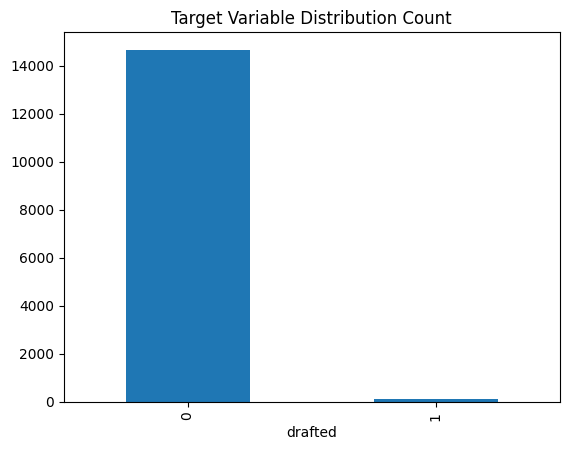

In [359]:
train[target_name].value_counts().plot(kind='bar', title='Target Variable Distribution Count')

<Axes: title={'center': 'Target Variable Distribution (%)'}, xlabel='drafted'>

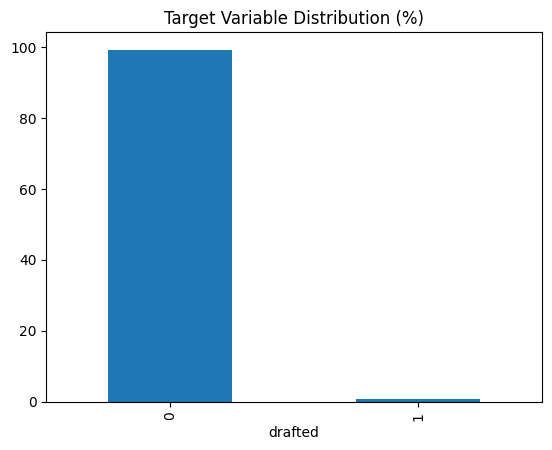

In [360]:
(train[target_name].value_counts(normalize=True) * 100).plot(kind='bar', title='Target Variable Distribution (%)')

In [361]:
# <Student to fill this section>
target_distribution_explanations = """
The target variable in our dataset is 'drafted', which records whether a player was selected in the NBA draft. Its values are binary, with most players marked as not drafted and only a smaller fraction marked as drafted. This imbalance is important because it means the model might easily learn to predict the majority class without truly identifying drafted players. While the variable is clean and consistent, one limitation is that it does not capture why a player was drafted, factors like team needs or injuries are not represented. Another issue is the temporal context: drafting trends can shift by year, but this binary label treats all seasons the same. Despite these challenges, the variable serves as a clear and measurable outcome for our models, and careful evaluation metrics like AUROC will help address imbalance concerns.
"""

In [362]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `\<Offensive Rating\>`

In [363]:
# <Student to fill this section>
train['Ortg'].describe()

count    14774.000000
mean        85.771707
std         34.164203
min          0.000000
25%         75.600000
50%         91.300000
75%        102.600000
max        407.300000
Name: Ortg, dtype: float64

In [364]:
train['Ortg'].isna().sum()

np.int64(0)

<Axes: >

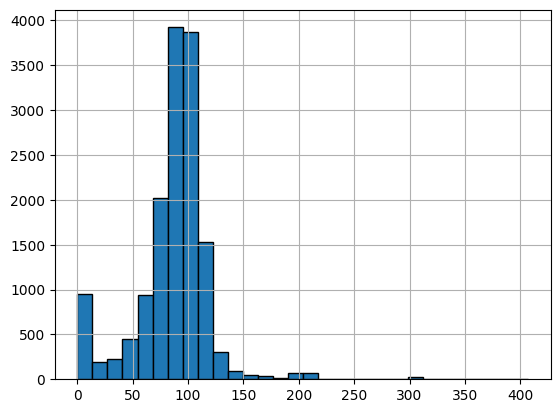

In [365]:
train['Ortg'].hist(bins=30, edgecolor='black')

<Axes: title={'center': 'Ortg'}, xlabel='drafted'>

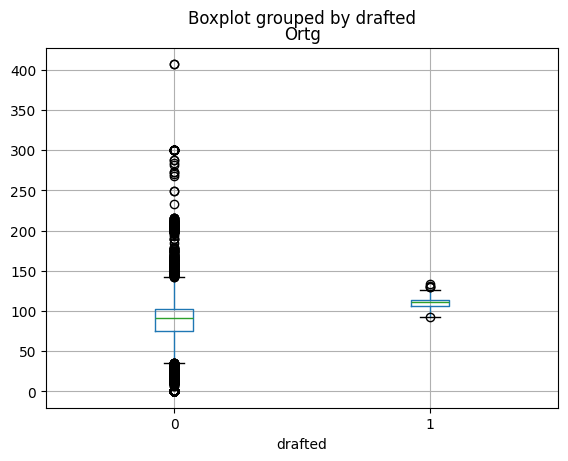

In [366]:
train.boxplot(column='Ortg', by=target_name)

In [367]:
train.groupby(target_name)['Ortg'].mean()

drafted
0     85.573629
1    110.373729
Name: Ortg, dtype: float64

In [368]:
# <Student to fill this section>
feature_1_insights = """
Offensive Rating (Ortg) measures how many points a player creates per 100 possessions, showing their scoring efficiency. Most players fall between 80–120, with only a few outliers going much higher. Drafted players usually have stronger ratings, suggesting teams value efficiency. Still, numbers can be skewed by team strength or limited games played, so context matters.
"""

In [369]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `\<True Shooting %\>`

In [370]:
# <Student to fill this section>
train['TS_per'].describe()

count    14774.000000
mean        44.566821
std         19.622173
min          0.000000
25%         38.820000
50%         48.285000
75%         54.090000
max        150.000000
Name: TS_per, dtype: float64

In [371]:
train['TS_per'].isna().sum()

np.int64(0)

In [372]:
train.groupby(target_name)['TS_per'].mean()

drafted
0    44.469749
1    56.623475
Name: TS_per, dtype: float64

<Axes: >

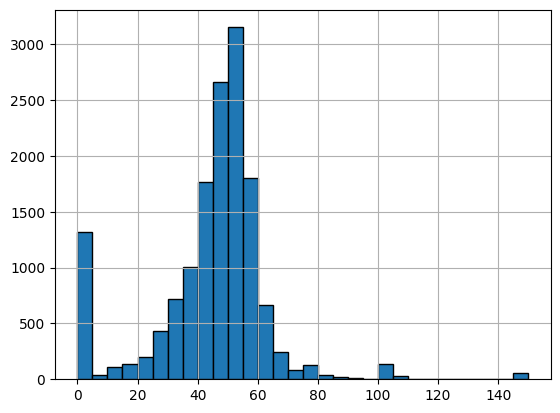

In [373]:
train['TS_per'].hist(bins=30, edgecolor='black')

<Axes: title={'center': 'TS_per'}, xlabel='drafted'>

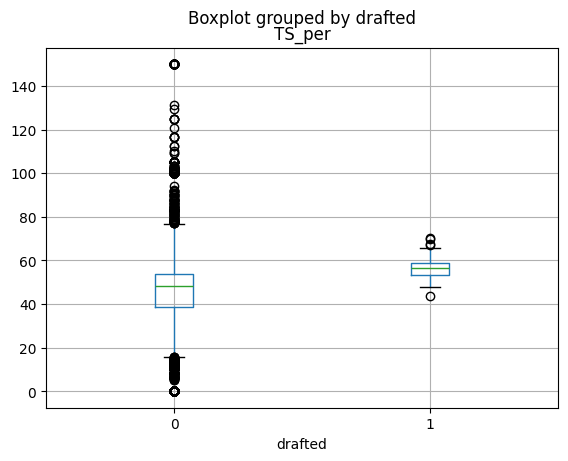

In [374]:
train.boxplot(column='TS_per', by=target_name)

In [375]:
# <Student to fill this section>
feature_2_insights = """
True Shooting % (TS_per) is a measure of overall scoring efficiency, factoring in two-pointers, three-pointers, and free throws. Most players cluster around the mid-40s to mid-60s range, with a few standing out at very high or low values. Drafted players on average show stronger shooting efficiency, suggesting that consistency in scoring is valued in draft decisions. A limitation is that the metric can be skewed for players with very few shot attempts, where even small changes in makes or misses produce extreme percentages.
"""

In [376]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `\<Assist %\>`


In [377]:
# <Student to fill this section>
train['AST_per'].describe()

count    14774.000000
mean         9.776100
std          9.906416
min          0.000000
25%          3.200000
50%          7.900000
75%         13.700000
max        100.000000
Name: AST_per, dtype: float64

In [378]:
train['AST_per'].isna().sum()

np.int64(0)

<Axes: >

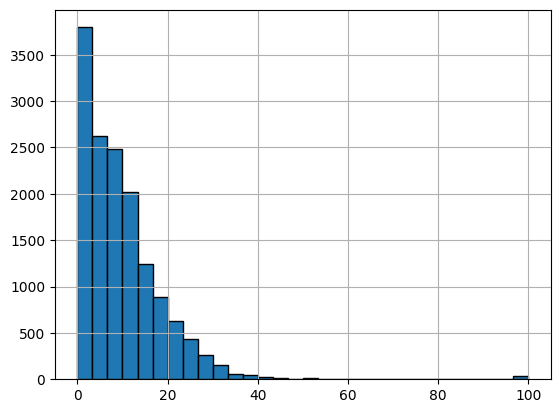

In [379]:
train['AST_per'].hist(bins=30, edgecolor='black')

<Axes: title={'center': 'AST_per'}, xlabel='drafted'>

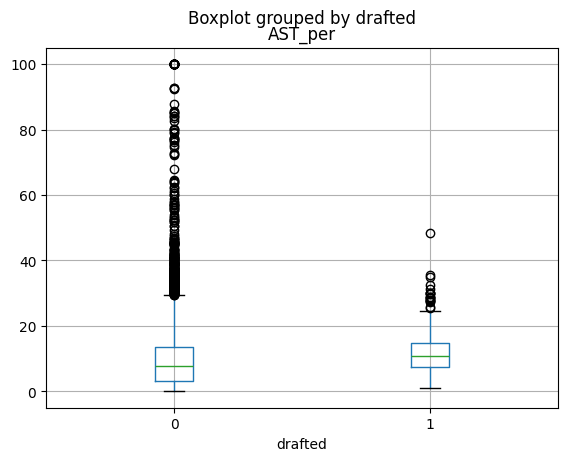

In [380]:
train.boxplot(column='AST_per', by=target_name)

In [381]:
train.groupby(target_name)['AST_per'].mean()

drafted
0     9.748335
1    13.224576
Name: AST_per, dtype: float64

In [382]:
# <Student to fill this section>
feature_7_insights = """
Assist % (AST_per) captures how often a player sets up teammates for made shots. Values are heavily skewed toward the low end, with a small group posting standout playmaking rates. Drafted players show higher averages than non-drafted, but the gap is modest rather than cleanly separated. Metric can be shaped by role, usage, and team system, so it signals creation ability but not the whole picture.
"""

In [383]:
# Do not modify this code
print_tile(size="h3", key='feature_7_insights', value=feature_7_insights)

### C.8 Explore Feature of Interest `\<Steal %\>`


In [384]:
# <Student to fill this section>
train['stl_per'].describe()

count    14774.000000
mean         1.669995
std          2.562866
min          0.000000
25%          0.600000
50%          1.400000
75%          2.200000
max        118.200000
Name: stl_per, dtype: float64

In [385]:
train['stl_per'].isna().sum()

np.int64(0)

<Axes: >

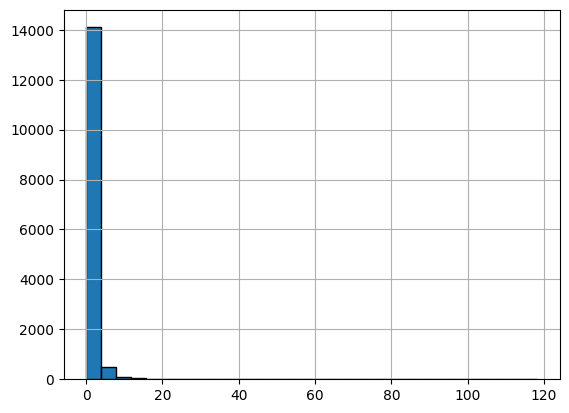

In [386]:
train['stl_per'].hist(bins=30, edgecolor='black')

<Axes: title={'center': 'stl_per'}, xlabel='drafted'>

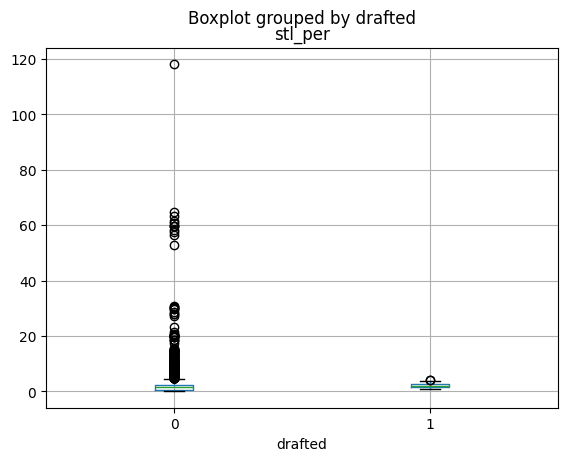

In [387]:
train.boxplot(column='stl_per', by=target_name)

In [388]:
train.groupby(target_name)['stl_per'].mean()

drafted
0    1.667338
1    2.000000
Name: stl_per, dtype: float64

In [389]:
# <Student to fill this section>
feature_n_insights = """
Steal % (stl_per) shows how often a player generates turnovers on defense. The distribution is heavily skewed toward very low values, with only a small group of players recording notable steal rates. Drafted players tend to post slightly higher averages, but the difference is not as pronounced as with offensive stats. A limitation here is that steals can depend on team defensive schemes and may not fully reflect a player’s overall defensive ability.
"""

In [390]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

### C.9 Explore Feature of Interest `\<Points\>`


In [391]:
train['pts'].describe()

count    14773.000000
mean         3.662676
std          3.623175
min          0.000000
25%          1.000000
50%          2.448300
75%          5.363600
max         27.375000
Name: pts, dtype: float64

In [392]:
train['pts'].isna().sum()

np.int64(1)

In [393]:
train['pts'] = train['pts'].fillna(0)

In [394]:
train['pts'].isna().sum()

np.int64(0)

<Axes: >

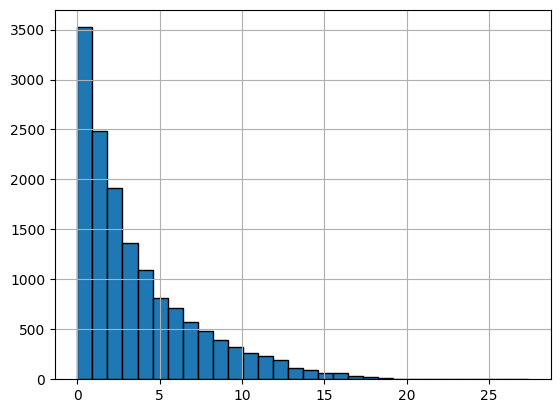

In [395]:
train['pts'].hist(bins=30, edgecolor='black')

<Axes: title={'center': 'pts'}, xlabel='drafted'>

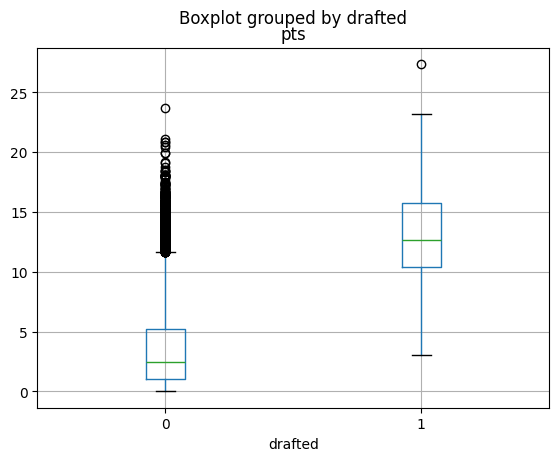

In [396]:
train.boxplot(column='pts', by=target_name)

In [397]:
train.groupby(target_name)['pts'].mean()

drafted
0     3.587173
1    13.009357
Name: pts, dtype: float64

In [398]:
# <Student to fill this section>
feature_n_insights = """
Points (pts) reflect a player’s raw scoring contribution and show a wide spread, with most players clustered at low to moderate levels and a few extreme high scorers. Drafted players, on average, score more than their non-drafted peers, which suggests that raw scoring ability remains an important draft consideration. However, this measure alone does not capture efficiency or context, meaning a player who scores a lot on poor shooting might still look strong in raw totals. Another issue is that some roles, such as defensive specialists, may not score much but still add value, so pts should be weighed alongside efficiency and all-around impact.
"""

In [399]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

### C.10 Explore Feature of Interest `\<Box Plus/Minus\>`


In [400]:
train['bpm'].describe()

count    14769.000000
mean        -4.126694
std          9.501254
min        -88.479400
25%         -7.096790
50%         -3.432640
75%         -0.129545
max        685.313000
Name: bpm, dtype: float64

In [401]:
train['bpm'].isna().sum()

np.int64(5)

<Axes: >

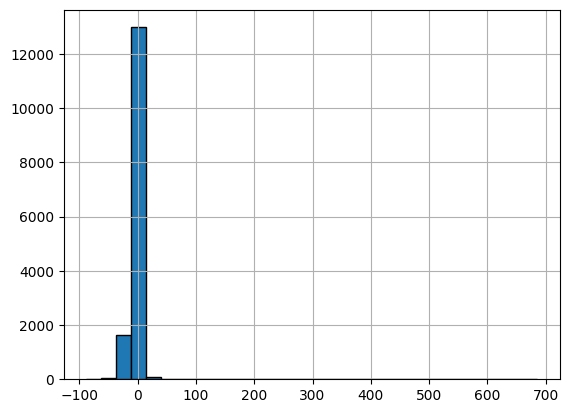

In [402]:
train['bpm'].dropna().hist(bins=30, edgecolor='black')

<Axes: >

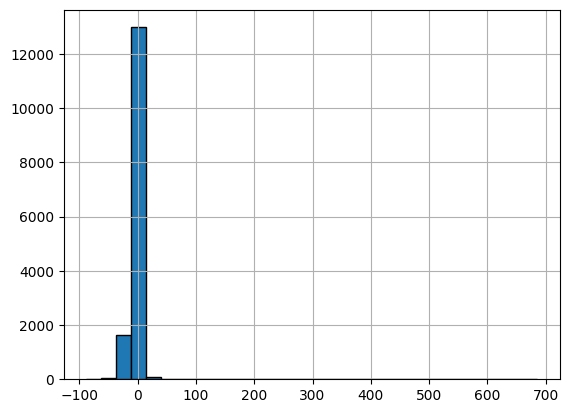

In [403]:
train['bpm'].hist(bins=30, edgecolor='black')

<Axes: title={'center': 'bpm'}, xlabel='drafted'>

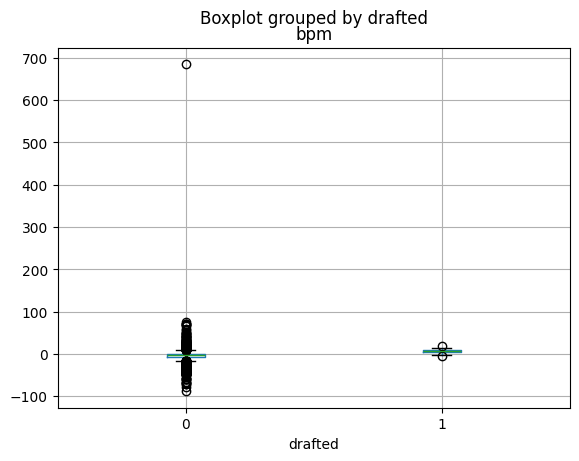

In [404]:
train.dropna(subset=['bpm']).boxplot(column='bpm', by=target_name)

In [405]:
train.groupby(target_name)['bpm'].mean()

drafted
0   -4.213341
1    6.631539
Name: bpm, dtype: float64

In [406]:
# <Student to fill this section>
feature_10_insights = """
Box Plus/Minus (bpm) gives a rough estimate of how much a player helps or hurts their team overall. Most players sit around slightly negative values, while drafted players tend to have higher averages, showing stronger all-around impact. The drawback is the presence of extreme outliers and missing entries, which can mislead the analysis if left unaddressed. It also leans heavily on team performance, sometimes giving extra credit to players on stronger squads.
"""

In [407]:
# Do not modify this code
print_tile(size="h3", key='feature_10_insights', value=feature_10_insights)

---
## D. Feature Selection


### D.1 Approach 1: "\<Correlation \>"


In [408]:
# <Student to fill this section>
corr = train.corr(numeric_only=True)[[target_name]].sort_values(by=target_name, ascending=False)

In [409]:
corr.head(10)

,drafted
drafted,1.000000
dunksmade,0.373588
dunksmiss_dunksmade,0.369440
porpag,0.295714
twoPM,0.288880
rimmade,0.283524
dporpag,0.274490
FTA,0.268576
FTM,0.266280
twoPA,0.265094


In [410]:
corr.tail(10)

,drafted
year,0.026408
blk_per,0.023812
ast_tov,0.020385
ORB_per,0.013267
ftr,0.011873
stl_per,0.011554
pfr,-0.013831
TO_per,-0.027493
drtg,-0.053877
adrtg,-0.081407


<Axes: title={'center': 'Correlation of Features with Drafted Feature'}>

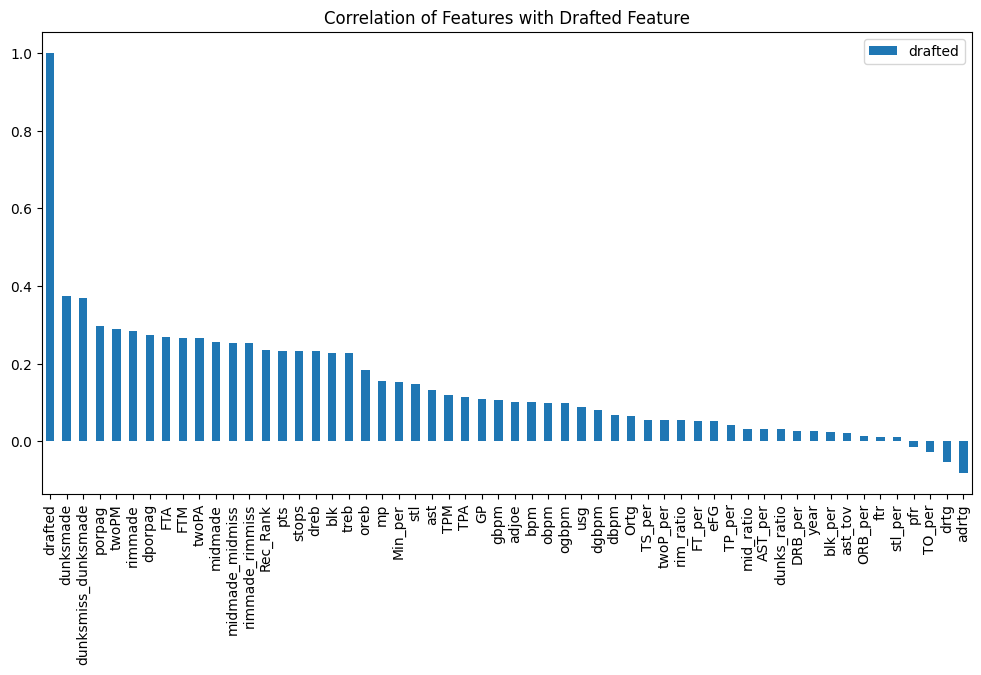

In [411]:
corr.plot(kind='bar', figsize=(12,6), title='Correlation of Features with Drafted Feature')

In [412]:
# <Student to fill this section>
feature_selection_1_insights = """
The correlation check shows that features tied to finishing ability and scoring efficiency, like dunksmade, porpag, and rimmade, have the strongest positive links with the chance of being drafted. On the other hand, defensive ratings such as adrtg and turnover-related stats show very weak or even negative relationships. This suggests that raw scoring impact is more directly valued in draft outcomes than defensive or efficiency balance measures. Still, correlation only captures linear patterns, so other methods are needed to fully understand feature importance.
"""

In [413]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach 2: "\<Mutual Information\>"


In [414]:
# <Student to fill this section>
from sklearn.feature_selection import mutual_info_classif

In [415]:
X_num = train.drop(columns=[target_name]).select_dtypes(include=['int64','float64'])

In [416]:
y = train[target_name]

In [417]:
mi_scores = mutual_info_classif(X_num.fillna(0), y, random_state=42)

In [418]:
mi_df = pd.DataFrame({'Feature': X_num.columns, 'MI_Score': mi_scores})

In [419]:
mi_df = mi_df.sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

In [420]:
mi_df.head(15)

,Feature,MI_Score
0,Rec_Rank,0.030838
1,dporpag,0.025694
2,stops,0.023741
3,porpag,0.023686
4,bpm,0.020602
5,FTA,0.020445
6,twoPM,0.020393
7,gbpm,0.019893
8,twoPA,0.019606
9,dreb,0.018997


In [421]:
# <Student to fill this section>
feature_selection_2_insights = """
The Mutual Information results show that features like Rec_Rank, dporpag, and stops provide the most useful signals in explaining draft outcomes. These capture a mix of player recognition, efficiency impact, and defensive contributions. Classic scoring stats like twoPM, FTA, and pts also rank highly, reinforcing the role of offensive production. Interestingly, metrics like Rec_Rank and stops rise higher here than in simple correlations, suggesting that non-linear patterns matter in how these features influence draft chances.
"""

In [422]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.3 Approach 3: "\<ANOVA F-test\>"

In [423]:
from sklearn.feature_selection import f_classif

In [424]:
X_num = train.drop(columns=[target_name]).select_dtypes(include=['int64','float64'])

In [425]:
y = train[target_name]

In [426]:
f_scores, p_values = f_classif(X_num.fillna(0), y)

In [427]:
anova_df = pd.DataFrame({
    "Feature": X_num.columns,
    "F_score": f_scores,
    "p_value": p_values
}).sort_values(by="F_score", ascending=False).reset_index(drop=True)

In [428]:
anova_df.head(15)

,Feature,F_score,p_value
0,dunksmade,2273.268306,0.000000e+00
1,dunksmiss_dunksmade,2214.238863,0.000000e+00
2,porpag,1415.549610,6.501310e-296
3,twoPM,1344.984461,6.867271e-282
4,dporpag,1203.409231,1.447510e-253
5,rimmade,1191.070174,4.377258e-251
6,FTA,1148.389060,1.724145e-242
7,FTM,1127.347186,3.038746e-238
8,twoPA,1116.569544,4.568354e-236
9,midmade,974.010316,3.964491e-207


In [429]:
# <Student to fill this section>
feature_selection_2_insights = """
The ANOVA F-test shows that scoring and finishing metrics such as dunksmade, porpag, and twoPM separate drafted from non-drafted players most strongly. These features have extremely high F-scores with near-zero p-values, confirming that the differences are very unlikely due to chance. Free throw attempts and makes, along with rim efficiency, also rank highly, reinforcing the importance of offensive production. Defensive measures like stops and rebounds appear further down but still show meaningful separation, suggesting that all-around impact adds value beyond scoring.
"""

In [430]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

## D.Z Final Selection of Features

In [431]:
# <Student to fill this section>

features_list = [ 'dunksmade', 'dunksmiss_dunksmade', 'porpag', 'twoPM', 'FTA', 'FTM', 'twoPA', 'rimmade', 'pts', 'midmade', 'dporpag', 'bpm', 'gbpm', 'stops', 'dreb', 'treb', 'Rec_Rank', 'adjoe', 'mid_ratio', 'rim_ratio', 'dunks_ratio', 'ast', 'conf', 'yr', 'type','drafted']

In [432]:
print(features_list)

['dunksmade', 'dunksmiss_dunksmade', 'porpag', 'twoPM', 'FTA', 'FTM', 'twoPA', 'rimmade', 'pts', 'midmade', 'dporpag', 'bpm', 'gbpm', 'stops', 'dreb', 'treb', 'Rec_Rank', 'adjoe', 'mid_ratio', 'rim_ratio', 'dunks_ratio', 'ast', 'conf', 'yr', 'type', 'drafted']


In [433]:
train_df = train[features_list]

In [434]:
print(train_df.columns.tolist())

['dunksmade', 'dunksmiss_dunksmade', 'porpag', 'twoPM', 'FTA', 'FTM', 'twoPA', 'rimmade', 'pts', 'midmade', 'dporpag', 'bpm', 'gbpm', 'stops', 'dreb', 'treb', 'Rec_Rank', 'adjoe', 'mid_ratio', 'rim_ratio', 'dunks_ratio', 'ast', 'conf', 'yr', 'type', 'drafted']


In [435]:
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_cols)

['dunksmade', 'dunksmiss_dunksmade', 'porpag', 'twoPM', 'FTA', 'FTM', 'twoPA', 'rimmade', 'pts', 'midmade', 'dporpag', 'bpm', 'gbpm', 'stops', 'dreb', 'treb', 'Rec_Rank', 'adjoe', 'mid_ratio', 'rim_ratio', 'dunks_ratio', 'ast', 'drafted']


In [436]:
categorical_cols = train_df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
print(categorical_cols)

['conf', 'yr', 'type']


In [437]:
# <Student to fill this section>
feature_selection_explanations = """
The features list balances raw performance, advanced impact, and player context. It keeps strong scoring and efficiency measures like porpag, twoPM, and FTA, while also adding defensive impact with stops and dreb. Extra numeric stats such as mid_ratio and ast broaden coverage of shot types and playmaking. Finally, including conf, yr, and type brings in categorical context, ensuring the model considers both player performance and situational factors.
"""

In [438]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation 'Missing Values Analysis'<put_name_here>

In [439]:
missing_vals = train_df.isnull().sum()
missing_vals

dunksmade              2075
dunksmiss_dunksmade    2075
porpag                    0
twoPM                     0
FTA                       0
FTM                       0
twoPA                     0
rimmade                2075
pts                       0
midmade                2075
dporpag                   5
bpm                       5
gbpm                      5
stops                     5
dreb                      1
treb                      1
Rec_Rank               9885
adjoe                     0
mid_ratio              3191
rim_ratio              3203
dunks_ratio            9388
ast                       1
conf                      0
yr                        0
type                      0
drafted                   0
dtype: int64

In [440]:
missing_prct = (missing_vals / len(train_df)) * 100
missing_prct

dunksmade              14.044944
dunksmiss_dunksmade    14.044944
porpag                  0.000000
twoPM                   0.000000
FTA                     0.000000
FTM                     0.000000
twoPA                   0.000000
rimmade                14.044944
pts                     0.000000
midmade                14.044944
dporpag                 0.033843
bpm                     0.033843
gbpm                    0.033843
stops                   0.033843
dreb                    0.006769
treb                    0.006769
Rec_Rank               66.908082
adjoe                   0.000000
mid_ratio              21.598755
rim_ratio              21.679978
dunks_ratio            63.544064
ast                     0.006769
conf                    0.000000
yr                      0.000000
type                    0.000000
drafted                 0.000000
dtype: float64

In [441]:
missing_summary = pd.DataFrame({
    'Missing_Count': missing_vals,
    'Missing_Percent': missing_prct.round(2)
}).sort_values(by='Missing_Percent', ascending=False)

print("Missing values summary:")
print(missing_summary)

Missing values summary:
                     Missing_Count  Missing_Percent
Rec_Rank                      9885            66.91
dunks_ratio                   9388            63.54
rim_ratio                     3203            21.68
mid_ratio                     3191            21.60
dunksmade                     2075            14.04
dunksmiss_dunksmade           2075            14.04
midmade                       2075            14.04
rimmade                       2075            14.04
dporpag                          5             0.03
stops                            5             0.03
gbpm                             5             0.03
bpm                              5             0.03
dreb                             1             0.01
treb                             1             0.01
ast                              1             0.01
porpag                           0             0.00
twoPM                            0             0.00
FTM                              0      

In [442]:
cols_to_drop = missing_summary[missing_summary['Missing_Percent'] > 50].index
print("Dropping columns:", list(cols_to_drop))

Dropping columns: ['Rec_Rank', 'dunks_ratio']


In [443]:
train_df = train_df.drop(columns=cols_to_drop)
print("Remaining columns:", train_df.columns)

Remaining columns: Index(['dunksmade', 'dunksmiss_dunksmade', 'porpag', 'twoPM', 'FTA', 'FTM',
       'twoPA', 'rimmade', 'pts', 'midmade', 'dporpag', 'bpm', 'gbpm', 'stops',
       'dreb', 'treb', 'adjoe', 'mid_ratio', 'rim_ratio', 'ast', 'conf', 'yr',
       'type', 'drafted'],
      dtype='object')


In [444]:
num_rows = train_df.shape[0]
num_rows

14774

In [445]:
still_present = [c for c in cols_to_drop if c in train_df.columns]
print("Any >50% missing columns still present? ->", still_present)

Any >50% missing columns still present? -> []


In [446]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14774 entries, 0 to 14773
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   dunksmade            12699 non-null  float64
 1   dunksmiss_dunksmade  12699 non-null  float64
 2   porpag               14774 non-null  float64
 3   twoPM                14774 non-null  int64  
 4   FTA                  14774 non-null  int64  
 5   FTM                  14774 non-null  int64  
 6   twoPA                14774 non-null  int64  
 7   rimmade              12699 non-null  float64
 8   pts                  14774 non-null  float64
 9   midmade              12699 non-null  float64
 10  dporpag              14769 non-null  float64
 11  bpm                  14769 non-null  float64
 12  gbpm                 14769 non-null  float64
 13  stops                14769 non-null  float64
 14  dreb                 14773 non-null  float64
 15  treb                 14773 non-null 

In [447]:
cols_with_missing_vals = [ 'rim_ratio', 'mid_ratio',  'midmade', 'dunksmiss_dunksmade', 'rimmade', 'dunksmade',  'gbpm', 'stops', 'dporpag', 'bpm', 'dreb', 'treb', 'ast']

In [448]:
from sklearn.impute import SimpleImputer

In [449]:
imputer = SimpleImputer(strategy='median')

In [450]:
train_df[cols_with_missing_vals] = imputer.fit_transform(train_df[cols_with_missing_vals])

In [451]:
train_df.isna().sum()

dunksmade              0
dunksmiss_dunksmade    0
porpag                 0
twoPM                  0
FTA                    0
FTM                    0
twoPA                  0
rimmade                0
pts                    0
midmade                0
dporpag                0
bpm                    0
gbpm                   0
stops                  0
dreb                   0
treb                   0
adjoe                  0
mid_ratio              0
rim_ratio              0
ast                    0
conf                   0
yr                     0
type                   0
drafted                0
dtype: int64

In [452]:
print(train_df.columns.tolist())

['dunksmade', 'dunksmiss_dunksmade', 'porpag', 'twoPM', 'FTA', 'FTM', 'twoPA', 'rimmade', 'pts', 'midmade', 'dporpag', 'bpm', 'gbpm', 'stops', 'dreb', 'treb', 'adjoe', 'mid_ratio', 'rim_ratio', 'ast', 'conf', 'yr', 'type', 'drafted']


In [453]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Rec_Rank and dunks_ratio had a very high percentage of missing values (over 50%), so keeping them would have meant losing most of the dataset if rows were dropped. For the other columns, the missing values were relatively low so those rows were imputed with median values which ensured the dataset remained complete without sacrificing too much data. This way, the dataset is kept reliable while still preserving most of the information.
"""

In [454]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation 'Duplicate Records Analysis'<put_name_here>

In [455]:
# <Student to fill this section>
duplicate_rows = train_df[train_df.duplicated(subset=[col for col in train_df.columns if col != 'drafted'])]
duplicate_rows

,dunksmade,dunksmiss_dunksmade,porpag,twoPM,FTA,FTM,twoPA,rimmade,pts,midmade,...,dreb,treb,adjoe,mid_ratio,rim_ratio,ast,conf,yr,type,drafted
9507,0.0,0.0,-0.164114,0,0,0,0,9.0,0.0000,4.0,...,0.0000,0.0000,-7.63273,0.3158,0.5586,0.0000,ACC,Fr,all,0
12312,0.0,0.0,-0.113298,0,2,2,2,0.0,0.2778,0.0,...,0.2778,0.3889,58.51370,0.0000,0.5586,0.0556,BSth,Fr,all,0
12313,0.0,0.0,1.759190,39,69,46,87,9.0,7.2903,4.0,...,1.8710,3.1613,107.86700,0.3158,0.5586,1.3871,BE,Fr,all,0
12314,0.0,0.0,-0.728365,12,32,22,49,9.0,2.2609,4.0,...,1.0435,1.6087,69.39880,0.3158,0.5586,1.0000,MAC,Fr,all,0
12315,0.0,0.0,-0.311529,19,23,17,44,13.0,2.4400,6.0,...,1.0000,1.2800,77.01080,0.3750,0.4643,1.2000,SWAC,Fr,all,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14769,5.0,6.0,-0.215540,26,29,15,72,19.0,2.4138,7.0,...,2.2069,2.9655,80.77890,0.2414,0.4419,0.8276,ACC,Fr,all,0
14770,0.0,0.0,-0.116464,7,15,6,18,9.0,1.6296,4.0,...,0.5556,0.7778,80.45770,0.3158,0.5586,0.3704,CUSA,Fr,all,0
14771,0.0,0.0,4.024600,134,185,148,293,9.0,16.5714,4.0,...,4.3571,6.0357,118.50400,0.3158,0.5586,2.7857,ACC,Fr,all,0
14772,0.0,0.0,-0.797078,0,5,2,6,0.0,0.6000,0.0,...,0.0000,0.1000,25.67860,0.0000,0.0000,0.2000,SWAC,Fr,all,0


In [456]:
train_df.describe()

,dunksmade,dunksmiss_dunksmade,porpag,twoPM,FTA,FTM,twoPA,rimmade,pts,midmade,...,bpm,gbpm,stops,dreb,treb,adjoe,mid_ratio,rim_ratio,ast,drafted
count,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,...,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000
mean,2.118248,2.389874,0.280661,25.389130,30.266482,20.152092,54.456410,16.418032,3.662428,8.263842,...,-4.126459,-4.134117,55.974850,1.269329,1.821773,82.273757,0.305822,0.545881,0.717300,0.007987
std,5.853432,6.402878,0.948095,31.946829,37.293688,26.550462,64.087138,20.977807,3.623177,11.517323,...,9.499654,9.087692,53.432667,1.125607,1.625365,33.564856,0.170348,0.190989,0.897234,0.089015
min,0.000000,0.000000,-4.714300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-88.479400,-176.493000,0.043033,0.000000,0.000000,-36.615900,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,-0.309601,2.000000,3.250000,2.000000,6.000000,3.000000,1.000000,1.000000,...,-7.094810,-7.073480,8.596790,0.428600,0.626150,70.950500,0.250000,0.500000,0.125000,0.000000
50%,0.000000,0.000000,0.067786,13.000000,16.000000,10.000000,31.000000,9.000000,2.448300,4.000000,...,-3.432640,-3.419650,40.998800,1.000000,1.400000,87.977900,0.315800,0.558600,0.400000,0.000000
75%,1.000000,2.000000,0.632708,37.000000,44.000000,28.000000,81.000000,22.000000,5.363600,10.000000,...,-0.130369,-0.114353,90.745025,1.827225,2.551700,100.430250,0.366700,0.626900,0.971400,0.000000
max,99.000000,105.000000,7.067140,279.000000,297.000000,236.000000,442.000000,213.000000,27.375000,124.000000,...,685.313000,112.161000,360.572000,8.636400,11.757600,310.580000,1.000000,1.000000,8.656200,1.000000


In [457]:
train_df = train_df.drop_duplicates(subset=[col for col in train_df.columns if col != 'drafted'])
train_df.describe()

,dunksmade,dunksmiss_dunksmade,porpag,twoPM,FTA,FTM,twoPA,rimmade,pts,midmade,...,bpm,gbpm,stops,dreb,treb,adjoe,mid_ratio,rim_ratio,ast,drafted
count,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,...,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000
mean,2.112745,2.386321,0.277098,25.351718,30.237024,20.102754,54.403217,16.389327,3.658338,8.246934,...,-4.112953,-4.117163,55.959474,1.267684,1.820112,82.313525,0.305787,0.546077,0.717911,0.007879
std,5.883043,6.442728,0.944184,31.797510,37.117818,26.382673,63.761664,20.923882,3.609707,11.489321,...,9.864253,9.155563,53.219520,1.118402,1.616357,33.493748,0.170043,0.191006,0.899342,0.088418
min,0.000000,0.000000,-4.714300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-88.479400,-176.493000,0.043033,0.000000,0.000000,-36.615900,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,-0.311376,2.000000,4.000000,2.000000,6.000000,3.000000,1.000000,1.000000,...,-7.113570,-7.073410,8.674730,0.434800,0.625000,71.013300,0.250000,0.500000,0.125000,0.000000
50%,0.000000,0.000000,0.067801,13.000000,16.000000,10.000000,31.000000,9.000000,2.466700,4.000000,...,-3.442330,-3.408550,41.148100,1.000000,1.400000,87.954800,0.315800,0.558600,0.400000,0.000000
75%,1.000000,2.000000,0.633207,37.000000,44.000000,28.000000,81.000000,21.000000,5.358550,10.000000,...,-0.128695,-0.124795,90.716700,1.827600,2.555600,100.402000,0.366700,0.625000,0.970600,0.000000
max,99.000000,105.000000,7.067140,279.000000,297.000000,236.000000,442.000000,213.000000,27.375000,124.000000,...,685.313000,112.161000,360.572000,8.636400,11.757600,310.580000,1.000000,1.000000,8.656200,1.000000


In [458]:
# <Student to fill this section>
data_cleaning_2_explanations = """
This step involved identifying and removing duplicate records from the dataset. Duplicate entries can distort results by over-representing certain values, leading to misleading insights. Eliminating these duplicates reduces dataset size but improves reliability, ensuring that the statistics reflect true patterns. This process strengthens the foundation for accurate analysis.
"""

In [459]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation 'Data Type Validation & Correction'<put_name_here>

In [460]:
# <Student to fill this section>
print(train_df.columns.tolist())

['dunksmade', 'dunksmiss_dunksmade', 'porpag', 'twoPM', 'FTA', 'FTM', 'twoPA', 'rimmade', 'pts', 'midmade', 'dporpag', 'bpm', 'gbpm', 'stops', 'dreb', 'treb', 'adjoe', 'mid_ratio', 'rim_ratio', 'ast', 'conf', 'yr', 'type', 'drafted']


In [461]:
print(train_df.dtypes)

dunksmade              float64
dunksmiss_dunksmade    float64
porpag                 float64
twoPM                    int64
FTA                      int64
FTM                      int64
twoPA                    int64
rimmade                float64
pts                    float64
midmade                float64
dporpag                float64
bpm                    float64
gbpm                   float64
stops                  float64
dreb                   float64
treb                   float64
adjoe                  float64
mid_ratio              float64
rim_ratio              float64
ast                    float64
conf                    object
yr                      object
type                    object
drafted                  int64
dtype: object


In [462]:
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_cols)

['dunksmade', 'dunksmiss_dunksmade', 'porpag', 'twoPM', 'FTA', 'FTM', 'twoPA', 'rimmade', 'pts', 'midmade', 'dporpag', 'bpm', 'gbpm', 'stops', 'dreb', 'treb', 'adjoe', 'mid_ratio', 'rim_ratio', 'ast', 'drafted']


In [463]:
for numcol in numerical_cols:
    train_df[numcol] = pd.to_numeric(train_df[numcol], errors='coerce')

In [464]:
categorical_cols = train_df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
print(categorical_cols)

['conf', 'yr', 'type']


In [465]:
for catcol in categorical_cols:
    train_df[catcol] = train_df[catcol].astype('category')

In [466]:
print(train_df.dtypes)

dunksmade               float64
dunksmiss_dunksmade     float64
porpag                  float64
twoPM                     int64
FTA                       int64
FTM                       int64
twoPA                     int64
rimmade                 float64
pts                     float64
midmade                 float64
dporpag                 float64
bpm                     float64
gbpm                    float64
stops                   float64
dreb                    float64
treb                    float64
adjoe                   float64
mid_ratio               float64
rim_ratio               float64
ast                     float64
conf                   category
yr                     category
type                   category
drafted                   int64
dtype: object


In [467]:
# <Student to fill this section>
data_cleaning_3_explanations = """
This step focused on validating and correcting the data types of the selected features. Numerical columns were confirmed as proper numeric values, while categorical columns such as conference, year, and type were converted from object format to category format. This ensures that numbers are treated as quantities for calculations, while labels are recognized as groups for classification. The adjustment improves both clarity of the dataset and efficiency for further analysis.
"""

In [468]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "\<Shooting Efficiency\>"


In [469]:
# <Student to fill this section>
train_df['shooting_eff'] = (train_df['twoPM'] + train_df['FTM']) / ((train_df['twoPA'] + train_df['FTA']).replace(0, np.nan))

In [470]:
train_df['shooting_eff'] = train_df['shooting_eff'].fillna(train_df['shooting_eff'].median())

In [471]:
print(train_df['shooting_eff'])

0        0.590909
1        0.400000
2        0.500000
3        0.482517
4        0.263158
           ...   
12307    0.511811
12308    0.000000
12309    0.000000
12310    0.511811
12311    0.511811
Name: shooting_eff, Length: 12311, dtype: float64


In [472]:
# <Student to fill this section>
test['shooting_eff'] = (test['twoPM'] + test['FTM']) / ((test['twoPA'] + test['FTA']).replace(0, np.nan))

In [473]:
test['shooting_eff'] = test['shooting_eff'].fillna(test['shooting_eff'].median())

In [474]:
print(test['shooting_eff'])

0       0.000000
1       0.657143
2       0.574713
3       0.461538
4       0.500000
          ...   
1292    0.200000
1293    0.000000
1294    0.000000
1295    0.500000
1296    0.526316
Name: shooting_eff, Length: 1297, dtype: float64


In [475]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Shooting Efficiency measures how well scoring chances at the rim and the line turn into points, not just how many shots are taken. Rewards players who finish inside and convert free throws with steady consistency. Higher values often signal smart shot selection and reliable touch near the basket. A tiny constant in the denominator avoids errors when attempts are zero.
"""

In [476]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "\<Dunk Ratio\>"


In [477]:
# <Student to fill this section>
train_df['dunk_ratio'] = train_df['dunksmade'] / train_df['pts'].replace(0, np.nan)

In [478]:
train_df['dunk_ratio'] = train_df['dunk_ratio'].fillna(train_df['dunk_ratio'].median())

In [479]:
print(train_df['dunk_ratio'])

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
12307    0.0
12308    0.0
12309    0.0
12310    0.0
12311    0.0
Name: dunk_ratio, Length: 12311, dtype: float64


In [480]:
# <Student to fill this section>
test['dunk_ratio'] = test['dunksmade'] / test['pts'].replace(0, np.nan)

In [481]:
test['dunk_ratio'] = test['dunk_ratio'].fillna(test['dunk_ratio'].median())

In [482]:
print(test['dunk_ratio'])

0       0.000000
1       0.245453
2       3.703704
3       0.372550
4       1.142857
          ...   
1292    0.000000
1293    0.000000
1294    0.000000
1295    0.000000
1296    0.000000
Name: dunk_ratio, Length: 1297, dtype: float64


In [483]:
# <Student to fill this section>
feature_engineering_2_explanations = """
Dunk Ratio measures share of scoring coming from dunks. Highlights explosive finishing and presence at the rim. Higher values often align with athleticism.
"""

In [484]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "\<rim_mid_ratio\>"

In [485]:
# <Student to fill this section>
train_df['rim_mid_ratio'] = np.where(train_df['midmade'] != 0,train_df['rimmade'] / train_df['midmade'],np.nan)

In [486]:
train_df['rim_mid_ratio'] = train_df['rim_mid_ratio'].fillna(train_df['rim_mid_ratio'].median())

In [487]:
print(train_df['rim_mid_ratio'])

0        2.25
1        2.25
2        2.25
3        2.25
4        2.25
         ... 
12307    2.25
12308    2.25
12309    2.25
12310    2.25
12311    2.25
Name: rim_mid_ratio, Length: 12311, dtype: float64


In [488]:
# <Student to fill this section>
test['rim_mid_ratio'] = np.where(test['midmade'] != 0,test['rimmade'] / test['midmade'],np.nan)

In [489]:
test['rim_mid_ratio'] = test['rim_mid_ratio'].fillna(test['rim_mid_ratio'].median())

In [490]:
print(test['rim_mid_ratio'])

0       2.500000
1       1.333333
2       5.750000
3       2.500000
4       3.333333
          ...   
1292    2.500000
1293    2.500000
1294    2.500000
1295    2.500000
1296    2.500000
Name: rim_mid_ratio, Length: 1297, dtype: float64


In [491]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Rim_mid_ratio captures the balance between rim scoring and midrange scoring. A ratio above one indicates greater emphasis on scoring at the rim compared to midrange.
"""

In [492]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.4 New Feature "\<rebound_share\>"

In [493]:
# <Student to fill this section>
train_df['rebound_share'] = np.where(
    train_df['treb'] != 0,
    train_df['dreb'] / train_df['treb'],
    np.nan
)

In [494]:
train_df['rebound_share'] = train_df['rebound_share'].fillna(train_df['rebound_share'].median())

In [495]:
print(train_df['rebound_share'])

0        0.872324
1        1.000000
2        0.711543
3        0.863646
4        0.272814
           ...   
12307    0.711543
12308    0.711543
12309    0.711543
12310    0.711543
12311    0.711543
Name: rebound_share, Length: 12311, dtype: float64


In [496]:
# <Student to fill this section>
test['rebound_share'] = np.where(
    test['treb'] != 0,
    test['dreb'] / test['treb'],
    np.nan
)

In [497]:
test['rebound_share'] = test['rebound_share'].fillna(test['rebound_share'].median())

In [498]:
print(test['rebound_share'])

0       0.857143
1       0.862024
2       0.560515
3       0.731684
4       0.711157
          ...   
1292    1.000000
1293    0.741716
1294    0.741716
1295    1.000000
1296    0.741716
Name: rebound_share, Length: 1297, dtype: float64


In [499]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Rebound_share represents the proportion of total rebounds that are defensive. Helps differentiate between players who clean the glass defensively versus those who grab more on offense. Higher values often signal strong defensive positioning and rebounding fundamentals.
"""

In [500]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.5 New Feature "\<assist_pts_ratio\>"

In [501]:
# <Student to fill this section>
train_df['assist_pts_ratio'] = np.where(
    train_df['pts'] != 0,
    train_df['ast'] / train_df['pts'],
    np.nan
)

In [502]:
train_df['assist_pts_ratio'] = train_df['assist_pts_ratio'].fillna(train_df['assist_pts_ratio'].median())

In [503]:
print(train_df['assist_pts_ratio'])

0        0.231080
1        0.000000
2        0.000000
3        0.387097
4        0.750088
           ...   
12307    0.152529
12308    0.152529
12309    0.152529
12310    0.152529
12311    0.152529
Name: assist_pts_ratio, Length: 12311, dtype: float64


In [504]:
# <Student to fill this section>
test['assist_pts_ratio'] = np.where(
    test['pts'] != 0,
    test['ast'] / test['pts'],
    np.nan
)

In [505]:
test['assist_pts_ratio'] = test['assist_pts_ratio'].fillna(test['assist_pts_ratio'].median())

In [506]:
print(test['assist_pts_ratio'])

0       0.133333
1       0.036352
2       0.106489
3       0.196073
4       0.061200
          ...   
1292    1.000000
1293    0.155744
1294    0.155744
1295    0.000000
1296    0.000000
Name: assist_pts_ratio, Length: 1297, dtype: float64


In [507]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Assist_pts_ratio shows how much playmaking occurs relative to scoring output. Higher values indicate stronger distribution skills compared with pure scoring. Useful for separating facilitators from high-volume scorers.
"""

In [508]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.6 New Feature "\<impact_index\>"

In [509]:
# <Student to fill this section>
train_df['impact_index'] = (train_df['bpm'] + train_df['gbpm'] + train_df['dporpag']) / 3

In [510]:
print(train_df['impact_index'])

0         1.518270
1       -11.120835
2        -0.797456
3         1.031594
4        -8.374273
           ...    
12307    -4.348277
12308   -14.869169
12309     0.870869
12310    -8.800471
12311    -7.058297
Name: impact_index, Length: 12311, dtype: float64


In [511]:
# <Student to fill this section>
test['impact_index'] = (test['bpm'] + test['gbpm'] + test['dporpag']) / 3

In [512]:
print(test['impact_index'])

0       -9.080655
1       -3.753337
2        1.298354
3       -2.050817
4       -1.107498
          ...    
1292    -6.697675
1293   -26.715910
1294   -31.809183
1295   -13.509445
1296    44.530390
Name: impact_index, Length: 1297, dtype: float64


In [513]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Impact_index combines three advanced statistics into a single averaged score. Reflects overall influence by merging box plus-minus, generic plus-minus, and defensive points per possession. Higher scores suggest stronger all-around contributions that scouts may value.
"""

In [514]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [515]:
features_list = ['dunksmade', 'dunksmiss_dunksmade', 'porpag', 'twoPM', 'FTA', 'FTM', 'twoPA', 'rimmade', 'pts', 'midmade', 'dporpag', 'bpm', 'gbpm',  'stops', 'dreb',  'treb', 'adjoe', 'mid_ratio', 'rim_ratio', 'ast', 'conf', 'yr', 'type']

In [516]:
# <Student to fill this section>
X = train_df[features_list + ['shooting_eff','dunk_ratio','rim_mid_ratio','rebound_share','assist_pts_ratio','impact_index']]

In [517]:
y = train_df[target_name].astype(int)

In [518]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [519]:
X_test = test[features_list + ['shooting_eff','dunk_ratio','rim_mid_ratio','rebound_share','assist_pts_ratio','impact_index']]

In [520]:
y_test = pd.Series(dtype=float)

In [521]:
# <Student to fill this section>
data_splitting_explanations = """
The features and target are separated to build a clear training structure. An 80/20 split ensures the model is trained on most data while still being validated on unseen rows. Stratification in traintest split 'stratify=y', keeps the drafted and non-drafted proportions balanced across splits. The test dataset is set aside in full, ready for later prediction.
"""

In [522]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

In [523]:
X_train

,dunksmade,dunksmiss_dunksmade,porpag,twoPM,FTA,FTM,twoPA,rimmade,pts,midmade,...,ast,conf,yr,type,shooting_eff,dunk_ratio,rim_mid_ratio,rebound_share,assist_pts_ratio,impact_index
3481,0.0,0.0,-1.046700,0,2,0,2,0.0,0.0000,0.0,...,0.1667,GWC,Fr,all,0.000000,0.00,2.250000,0.666700,0.152529,-8.738945
850,0.0,0.0,-0.634318,29,61,32,56,9.0,3.0000,4.0,...,2.0938,ASun,Fr,all,0.521368,0.00,2.250000,0.893617,0.697933,-0.808033
2049,9.0,10.0,-0.294491,46,53,20,103,31.0,4.0000,15.0,...,0.5357,CAA,Fr,all,0.423077,2.25,2.066667,0.624063,0.133925,-2.095583
5375,0.0,0.0,-0.664011,19,34,24,48,7.0,3.8519,12.0,...,1.0000,SB,Fr,all,0.524390,0.00,0.583333,0.805595,0.259612,-2.350770
7612,0.0,0.0,0.178631,6,7,4,20,2.0,2.2632,4.0,...,0.5263,ACC,Fr,all,0.370370,0.00,0.500000,0.882419,0.232547,0.147725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8225,0.0,0.0,0.728550,46,77,57,123,28.0,7.3125,19.0,...,1.5312,CAA,Fr,all,0.515000,0.00,1.473684,0.800000,0.209395,-2.350103
1451,0.0,0.0,-0.321753,0,0,0,0,9.0,0.0000,4.0,...,0.0000,MAC,Fr,all,0.511811,0.00,2.250000,0.711543,0.152529,-3.988188
1913,1.0,1.0,0.044774,3,7,2,4,2.0,0.8000,1.0,...,0.5000,MEAC,Fr,all,0.454545,1.25,2.000000,0.571429,0.625000,-3.108356
6074,0.0,0.0,-0.526157,0,0,0,1,0.0,0.0000,0.0,...,0.1875,BE,Fr,all,0.000000,0.00,2.250000,1.000000,0.152529,-7.832092


In [524]:
y_train

3481    0
850     0
2049    0
5375    0
7612    0
       ..
8225    0
1451    0
1913    0
6074    0
9875    0
Name: drafted, Length: 9848, dtype: int64

### G.2 Data Transformation "\<One-Hot Encoding Categorical Features\>"

In [525]:
# <Student to fill this section>
categorical_cols = train_df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
print(categorical_cols)

['conf', 'yr', 'type']


In [526]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [527]:
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

In [528]:
preproc = ColumnTransformer(
    transformers=[('ohe', ohe, categorical_cols)],
    remainder='passthrough'
)

In [529]:
_ = preproc.fit(X_train)

In [530]:
ohe_names = preproc.named_transformers_['ohe'].get_feature_names_out(categorical_cols).tolist()
num_names = [c for c in X_test.columns if c not in categorical_cols]
all_names = ohe_names + num_names

In [531]:
X_train_mat = preproc.transform(X_train)

In [532]:
X_val_mat   = preproc.transform(X_val)

In [533]:
X_test_mat  = preproc.transform(X_test)

In [534]:
X_train = pd.DataFrame(X_train_mat, columns=all_names, index=X_train.index)

In [535]:
X_val = pd.DataFrame(X_val_mat, columns=all_names, index=X_val.index)

In [536]:
X_test = pd.DataFrame(X_test_mat, columns=all_names, index=X_test.index)

In [537]:
# <Student to fill this section>
data_transformation_1_explanations = """
Transformed categorical features into numeric indicator columns while leaving numeric fields untouched for a clean feature matrix. Fitted the encoder (One-Hot Encoding used here) on training data and applies the same mapping to validation and test, keeping identical columns and order across splits; unseen categories are safely ignored.
"""

In [538]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "\<Scaling Numerical Features\>"

In [539]:
# <Student to fill this section>
from sklearn.preprocessing import StandardScaler

In [540]:
num_cols = [c for c in X_train.columns if c not in ohe_names]

In [541]:
scaler = StandardScaler()

In [542]:
X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])

In [543]:
X_val.loc[:, num_cols] = scaler.transform(X_val[num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])

In [544]:
# <Student to fill this section>
data_transformation_3_explanations = """
Scaling numerical features of datasets using StandardScaler, which standardizes features before feeding them into a model. Thereby ensuring that all datasets are on the same standardized scale
"""

In [545]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [546]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

In [547]:
# <Student to fill this section>
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.calibration import calibration_curve

In [548]:
# <Student to fill this section>
performance_metrics_explanations = """
AUROC measures how well positive cases are ranked above negative cases across all thresholds. It handles uneven class balance and does not depend on a single cutoff, giving a fair view of separation. Higher AUROC reflects cleaner ordering of drafted versus non-drafted players, matching the project’s success measure. Log loss penalizes overconfident wrong probabilities and encourages careful probability estimates. Brier score measures the mean squared error of probabilities, offering a simple view of calibration and sharpness. The calibration curve provides a visual check to see whether predicted probabilities match observed frequencies.
"""

In [549]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm


In [550]:
# <Student to fill this section>
from sklearn.dummy import DummyClassifier

In [551]:
# <Student to fill this section>
algorithm_selection_explanations = """
A simple baseline model that predicts using class proportions from the training data. Sets a clear performance floor to judge later models. Fast to fit and stable, making validation checks straightforward.
"""

In [552]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters


In [553]:
# <Student to fill this section>
clf = DummyClassifier(strategy='prior', random_state=42)

In [554]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Baseline model configured to follow class proportions from training labels. Strategy 'prior' produces stable probability outputs independent of features. Parameter random_state=42 fixes randomness for reproducible behavior. Configuration establishes a clear performance floor before evaluating stronger models.
"""

In [555]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [556]:
# <Student to fill this section>
clf.fit(X_train, y_train)

DummyClassifier(random_state=42)

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [557]:
# <Student to fill this section>
y_train_prob = clf.predict_proba(X_train)[:, 1]

In [558]:
y_val_prob = clf.predict_proba(X_val)[:, 1]

In [559]:
y_test_prob = clf.predict_proba(X_test)[:, 1]

In [560]:
#def compute_auroc(y_true, y_proba):
#    return roc_auc_score(y_true, y_proba)

In [561]:
def eval(y_1, y_pred, label=""):
    lolo = log_loss(y_1, y_pred)
    bsl = brier_score_loss(y_1, y_pred)
    aucr = roc_auc_score(y_1, y_pred)
    print(f"=== {label} Metrics ===")
    print(f"Log Loss: {lolo:.4f} | Brier Score: {bsl:.4f} | AUROC: {aucr:.4f}\n")

In [562]:
eval(y_train, y_train_prob, "Train")

=== Train Metrics ===
Log Loss: 0.0462 | Brier Score: 0.0079 | AUROC: 0.5000



In [563]:
eval(y_val, y_val_prob, "Validation")

=== Validation Metrics ===
Log Loss: 0.0452 | Brier Score: 0.0077 | AUROC: 0.5000



In [564]:
cal_true_train, cal_pred_train = calibration_curve(y_train, y_train_prob, n_bins=10, strategy='uniform')
cal_true_train, cal_pred_train

(array([0.00792039]), array([0.00792039]))

In [565]:
cal_true_val, cal_pred_val = calibration_curve(y_val, y_val_prob, n_bins=10, strategy='uniform')
cal_true_val, cal_pred_val

(array([0.00771417]), array([0.00792039]))

In [566]:
# <Student to fill this section>
model_performance_explanations = """
Dummy baseline outputs a constant draft probability near the class prevalence (~0.8%), yielding AUROC = 0.50 on train and validation, which reflects no ranking skill. Log loss (~0.046) and Brier score (~0.0078) appear low mainly because positives are rare, not because predictions separate players. Calibration is flat and close to the true rate, meaning probabilities are steady but uninformative. This establishes a performance floor, meaningful modeling needs AUROC above 0.50 while keeping probability quality reasonable.
"""

In [567]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

In [568]:
submission = test[['player_id']].copy()

In [569]:
submission[target_name] = y_test_prob

In [570]:
submission.to_csv(at.folder_path / 'submission_dummy.csv', index=False)

In [571]:
# <Student to fill this section>
business_impacts_explanations = """
AUROC = 0.50 and flat calibration at the base rate provide no ranking power, so scouting priority would mirror random selection and add little planning value. False positives at this level divert travel, time, and budget toward low-probability players; false negatives allow genuine prospects to be taken by competitors, reducing draft capital efficiency and roster value. Poor ranking also weakens draft-slot strategy, increasing the chance of reaching early or missing optimal windows, with downstream salary-cap and opportunity costs. Until ranking rises meaningfully above 0.50 with steady calibration, treat this baseline as a prevalence benchmark rather than a decision tool.
"""

In [572]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## K. Project Outcomes

In [573]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [574]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [575]:
# <Student to fill this section>
experiment_results_explanations = """
The dummy model does not guide scouting decisions as the outcome shows no ranking ability, draft rate is tiny, ratio features are heavy-tailed, probabilities sit near the base rate, and encoding/scaling behave as expected. Further work is justified because stronger learning methods and better imbalance handling may reveal signal in season stats and engineered features. Next step: logistic regression
"""

In [576]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)